In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import re
import pickle
import scipy
import os
import scipy.stats as stats
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import KFold, train_test_split, GridSearchCV
from copy import deepcopy
from sklearn.utils import shuffle
from IPython.display import display, HTML
from sklearn.metrics import mean_squared_error, make_scorer, r2_score
from warnings import simplefilter
import warnings
# ignore all future warnings
from sklearn.exceptions import DataConversionWarning, FitFailedWarning
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore", category=DataConversionWarning)
warnings.filterwarnings("ignore", category=FitFailedWarning)
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import AnovaRM
from statsmodels.regression.mixed_linear_model import MixedLM
from statsmodels.formula.api import ols
display(HTML("<style>.container { width:85% !important; }</style>"))
sns.set_context(rc={'lines.linewidth': 2.5,
					'axes.labelsize': 25,
					'axes.titlesize': 19.200000000000003,
					'font.size': 25,
					'xtick.major.width': 8,
					'ytick.major.width': 8,
					'xtick.major.size':6,
					'ytick.major.size':6,
					'axes.linewidth':4})

Inits

In [ ]:
full_data = pd.read_pickle('multifiber_data_reviews.pickle')
# region and indexing-related variables / functions
region_ids = ['PrL (E)', 'PrL (I)', 'vLS (E)', 'vLS (I)', 'POA (E)', 'POA (I)',
	'BNST (E)', 'BNST (I)', 'AH (E)', 'AH (I)', 'MeA (E)', 'MeA (I)',
	'VMH (E)', 'VMH (I)', 'PAG (E)', 'PAG (I)', 'PMv (E)', 'PMv (I)', 'LHb (E)', 'LHb (I)',
	'PA (E)', 'PA (I)', 'NAc (DA)'] # populations
indices = {val: idx for idx, val in enumerate(region_ids)} # dictionary with IDs for remapping
agg_animals = ['3095', '3096', '3097', '4013', '4014', '4015', '4016', '91R2', '30L', '30B', '31R2', '29L2']
obs_animals = ['30R2', '29L', '86L', '87L2', '927R', '927L', '933R', '1162B', '1185']
non_animals = ['87R2', '87L', '87B', '86L2', '583L2', '583B', '1162L2', '1162R']
animals = np.concatenate([agg_animals, obs_animals, non_animals])

In [4]:
def format4analysis(full_data, animal_ID, binary_labels='attack labels', exp='aggression'):

	sessions = list(full_data.keys())
	region_index, region_id = pd.factorize(region_ids)
	epochs = [[0, 3], [3, 6], [6, 9], [9, 12], [12, 15], [15, 18], [18, 21], [21,24], [24, 28]]
	f = np.max([full_data[session].shape[0] for session in sessions])

	traces_lib = np.empty((f, len(region_index), 27))
	traces_lib[:] = np.nan
	
	# Initialize not_na_cols to handle case where no sessions are found
	not_na_cols = []

	# package recordings into traces_lib array

	if exp == 'aggression':
		sessions = [x for x in sessions if '_balbc_' in x or '_mCD1_' in x]
	elif exp == 'observation':
		sessions = [x for x in sessions if '_obs_' in x or '_OBSmCD1_' in x]
	elif exp == 'nonsocial':
		sessions = [x for x in sessions if '_toy_' in x or '_toyCD1_' in x]
	else:
		raise Exception("Please specify experience type as 'aggression' or 'observation'.")

	# Get matching sessions for this animal
	matching_sessions = [x for x in sessions if animal_ID in x]
	
	if not matching_sessions:
		print(f"Warning: No sessions found for animal {animal_ID}")
	
	for i, sesh in enumerate(matching_sessions):

		# format traces from each session to fit the big nan array above
		s = full_data[sesh]
		not_na_cols = s.columns[s.notna().all()].tolist()
		if s.shape[0] < f:
			nan_pad = np.zeros((f-s.shape[0], s.shape[1]))
			nan_pad[:] = np.nan
			nan_pad = pd.DataFrame(nan_pad, columns=s.columns)
			s = pd.concat([s, nan_pad], axis=0)

		# copy columns at specific locations
		for idx, roi in zip(region_index, region_id):
			try: 
				traces_lib[:, idx, i] = s[roi]
			except KeyError:
				traces_lib[:, idx, i] = np.nan

	# separate into epochs

	d1 = traces_lib[:, :, epochs[0][0]:epochs[0][1]]
	d2 = traces_lib[:, :, epochs[1][0]:epochs[1][1]]
	d3 = traces_lib[:, :, epochs[2][0]:epochs[2][1]]
	d4 = traces_lib[:, :, epochs[3][0]:epochs[3][1]]
	d5 = traces_lib[:, :, epochs[4][0]:epochs[4][1]]
	d6 = traces_lib[: ,:, epochs[5][0]:epochs[5][1]]
	d7 = traces_lib[: ,:, epochs[6][0]:epochs[6][1]]
	d8 = traces_lib[: ,:, epochs[7][0]:epochs[7][1]]
	d9 = traces_lib[: ,:, epochs[8][0]:epochs[8][1]]
	trial_comps = [d1, d2, d3, d4, d5, d6, d7, d8, d9] 

	return trial_comps, not_na_cols

def produce_XY(epoch, orig_idx):
	
	filtered_sessions = epoch[~np.isnan(epoch).all(axis=1)]
	
	X_idxs = [x for x in np.arange(filtered_sessions.shape[1]) if orig_idx != x]
	X = filtered_sessions[:, X_idxs]
	orig_X = X.copy()
	if np.isnan(X).any(axis=0).any(): # remove columns with nan
		has_nan = np.isnan(X).any(axis=0)
		X = X[:, ~has_nan]
	y_init = filtered_sessions[:, orig_idx]
	y = y_init.reshape(-1,1)

	return X, y

def fit_ridge(X, y, verbose=0):

	# Split dataset
	X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, shuffle=False)

	# Define the hyperparameters to search over
	param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

	# Define ridge regression model
	model = Ridge(fit_intercept=True, normalize=True)

	# Use GridSearchCV to perform a grid search with cross-validation
	# grid_search = GridSearchCV(model, param_grid, cv=3, scoring=make_scorer(r2_score))
	grid_search = GridSearchCV(model, param_grid, cv=None, scoring=make_scorer(r2_score))

	# Fit the grid search to the training data
	grid_search.fit(X, y)

	# Get the best hyperparameters found by the grid search
	best_params = grid_search.best_params_
	if verbose == 1:
		print('Best hyperparameters:', grid_search.best_params_)
		print('Best score:', grid_search.best_score_)

	# Train a new SVM classifier using the best hyperparameters
	best_model = Ridge(**best_params, fit_intercept=True, normalize=True) # rbf
	
	return X_train, X_test, y_train, y_test, best_model, grid_search.best_score_

def string_mapper(string_list, index):
	"""
	Maps a list of strings to indices in ascending order, and returns a function to retrieve the string for a given index.
	"""
	index_map = {i: string_list[i] for i in range(len(string_list))}
	
	def get_string(index):
		"""
		Returns the string corresponding to the given index in the mapping.
		"""
		return index_map[index]
	
	return get_string(index)

def format_weights(fold_weights, global_weights, rois):
	
	if fold_weights.shape[0] < global_weights.shape[0]:
		truncated_weights = np.zeros((global_weights.shape[0]))
		pres_idxs, miss_idxs = get_indices(rois)
		truncated_weights[pres_idxs] = np.array(np.mean(fold_weights, axis=1))
		truncated_weights[miss_idxs] = np.nan
		return truncated_weights
	else:
		return np.mean(fold_weights, axis=1)
	
def get_indices(partial_list):
	present_indices = [indices[val] for val in partial_list if val in indices]
	not_present = [val for val in np.arange(len(region_ids)) if val not in present_indices]
	return present_indices, not_present
	
def add_nan_values(matrix, rois, n_features=22):
	
	if len(rois) < n_features: 
		
		# Get roi indices
		pres_idxs, miss_idxs = get_indices(rois)
		# Create a copy of the original matrix to avoid modifying it
		matrix_copy = matrix.copy()
		# Create a 1D boolean mask that indicates where to add NaN values
		nan_mask = np.zeros(matrix_copy.shape[2], dtype=bool)
		print(miss_idxs)
		nan_mask[miss_idxs] = True
		# Add NaN values to the matrix
		matrix_copy = np.insert(matrix_copy, miss_idxs, np.nan, axis=2)
				
		return matrix_copy
	
	else:
		
		return matrix
	
def permutation_test(model, X_train, y_train, X_test, y_test, coefficients, rois, region_idx, n_permutations=100):
	
	shuf_model = deepcopy(model)
	max_coefs = np.zeros((n_permutations, 22))
	shuf_kos = np.zeros((n_permutations, 22))
	
	# Perform the permutations
	for i in range(n_permutations):
		
		# Shuffle the target variable (y)
		y_shuffled = shuffle(y_train)

		# Fit the model to the shuffled data
		shuf_model.fit(X_train, y_shuffled)
		shuf_best_score = r2_score(y_test, shuf_model.predict(X_test))

		# Store the maximum coefficient from the shuffled data
		max_coefs[i, :] = format_shuffled_weights(shuf_model.coef_, max_coefs, rois, region_idx)
		
		# Do knockout on shuffled model
		shuf_knockouts = np.zeros((shuf_model.coef_.shape[1]))
		for shuf_idx in np.arange(X_train.shape[1]):
			shuf_ko_model = deepcopy(shuf_model)
			new_shuf_coef=shuf_ko_model.coef_.copy()
			new_shuf_coef[:, shuf_idx] = 0.
			shuf_ko_model.coef_ = new_shuf_coef
			shuf_y_pred = shuf_ko_model.predict(X_test)
			shuf_ko_score = r2_score(y_test, shuf_y_pred)
			if shuf_ko_score < 0:
				shuf_ko_score = 0
			shuf_knockout_score_difference = shuf_best_score - shuf_ko_score
			if shuf_knockout_score_difference < 0:
				shuf_knockout_score_difference = 0
			shuf_knockouts[shuf_idx] = shuf_knockout_score_difference
		shuf_knockouts = shuf_knockouts.reshape((1, shuf_model.coef_.shape[1]))
			
		shuf_kos[i, :] = format_shuffled_weights(shuf_knockouts, shuf_kos, rois, region_idx)
		
	return max_coefs, shuf_kos

## Cluster by cluster regressions - E vs I

Here we're running a separate model for each cluster for each day. Mode is OLS from statsmodels.

#### Local E vs I:

### Multi-area model

In [6]:
def grab_cluster_idxs(full_data, animal_ID, exp='aggression'):

	sessions = list(full_data.keys())

	if exp == 'aggression':
		sessions = [x for x in sessions if '_balbc_' in x or '_mCD1_' in x if animal_ID in x]
	elif exp == 'observation':
		sessions = [x for x in sessions if '_obs_' in x or '_OBSmCD1_' in x if animal_ID in x]
	elif exp == 'nonsocial':
		sessions = [x for x in sessions if '_toy_' in x or '_toyCD1_' in x if animal_ID in x]
	else:
		raise Exception("Please specify experience type as 'aggression' or 'observation'.")

	unsupervised_labels_4_all = []
	for session in sessions:
		d_labels = full_data[session]['unsupervised labels'].values
		placeholder = np.zeros((len(d_labels), 13))
		for i in np.arange(13):
			cluster_idx = np.where(d_labels==i+1)[0]
			placeholder[cluster_idx, i] = 1
		unsupervised_labels_4_all.append(placeholder)

	return unsupervised_labels_4_all

Here we employ a constrained model approach on a cluster by cluster basis

First approach is to do this without behavior:

In [6]:
new_idx = np.array([12, 16, 8, 4, 10, 20, 6, 14, 2, 0, 18])
norm_idx = (new_idx/2).astype(int)
all_labels = [x.replace(' (E)', '').replace(' (I)', '').replace(' (DA)','') for x in np.array(region_ids)[new_idx]]

In [ ]:
np.random.seed(42)
constrained_idxs = np.array([16, 8, 4, 10, 20, 14, 13, 17, 9, 5, 11, 21]) # PMV, PAG, MEA and VMH <-------------------------------------
scores_const = np.zeros((27, len(animals)))
weights_const = np.zeros((len(constrained_idxs), 27, len(animals)))
knockouts_const = weights_const.copy()
pbar = tqdm(enumerate(animals), total=len(animals)) # progress bar

for a, animal in pbar:
	pbar.set_description('Processing animal %i' % a)
	
	# load animal data
	if a <= 11:
		exp = 'aggression'
	elif a <= 20: 
		exp = 'observation'
	else:
		exp = 'nonsocial'

	trial_comps, rois = format4analysis(full_data, animal, exp=exp)
	rois = rois[:-2]
	norm_indices = [i for i, item in enumerate(region_ids) if item in set(rois)]
	trial_comps = np.concatenate(trial_comps, axis=2)
	
	# create arrays for storage of weights and % drop across epochs
	epoch_scores = np.zeros((trial_comps.shape[2]))
	epoch_scores[:] = np.nan
	epoch_weights = np.zeros((len(constrained_idxs), trial_comps.shape[2]))
	epoch_weights[:] = np.nan
	epoch_knockouts = epoch_weights.copy()
	
	# containers for cross-validated score, weights and knockouts
	
	for e in np.arange(trial_comps.shape[-1]):
		epoch = trial_comps[:, :, e]
		for region_idx, orig_idx in enumerate(norm_indices):
			if orig_idx != 12: # only VMH
				continue
			
			# format y
			y = epoch[:, region_idx]
			y = y[~np.isnan(y)].reshape(-1,1)

			# format X
			X = epoch[:, constrained_idxs]
			X = X[:, ~np.all(np.isnan(X), axis=0)]
			X = X[~np.any(np.isnan(X), axis=1)]
			orig_X_shape = X.shape
			new_X_shape = X.shape
			if new_X_shape[1] < len(constrained_idxs): # if PMv is missing
				continue

			try:
				# fit model
				model = sm.GLM(y, X).fit()
				best_score = r2_score(y, model.predict(X))
				if best_score<0:
					best_score=0
				epoch_scores[e] = best_score
				epoch_weights[:, e] = model.params.flatten()
				# perform region knockouts
				knockouts = np.zeros((X.shape[1]))
				for knockout_idx in np.arange(X.shape[1]):
					avg_ko = []
					for n in np.arange(5):
						X_shuffled = X.copy()
						np.random.shuffle(X_shuffled[:, knockout_idx])
						y_pred = model.predict(X_shuffled)
						ko_score = r2_score(y, y_pred)
						if ko_score < 0:
							ko_score = 0
						avg_ko.append(ko_score)
					ko_score = np.mean(avg_ko) 
					knockout_score_difference = best_score - ko_score
					# knockout_score_difference = ((best_score - ko_score) / best_score) * 100
					if knockout_score_difference < 0:
						knockout_score_difference = 0
					knockouts[knockout_idx] = knockout_score_difference
				epoch_knockouts[:, e] = knockouts

			except ValueError: # in case y is nan
				# print('Skipping %s' % region_ids[population])
				continue

	scores_const[:, a] = epoch_scores
	weights_const[:, :, a] = epoch_weights
	knockouts_const[:, :, a] = epoch_knockouts

			

	

Processing animal 28: 100%|██████████| 29/29 [02:03<00:00,  4.25s/it]


In [ ]:
# Gather tables
all_tables = {}
animals2exclude = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24])
sessions2exclude = [0, 24] # for NON
weights2map = np.transpose(knockouts_const, [1,0,2])
# weights2map = np.abs(weights2map)


all_tables = []
for r, roi in enumerate(constrained_idxs):
	table = pd.DataFrame(columns=['cross_day', 'cross_session', 'within_day', 'subject', 'dependent_variable'])
	for animal in np.arange((len(np.concatenate([agg_animals, obs_animals, non_animals]))))[animals2exclude]:
		sample = weights2map[sessions2exclude[0]:sessions2exclude[1], r, animal]
		cross_day_info = np.repeat(np.arange(9), 3)[sessions2exclude[0]:sessions2exclude[1]].astype(float)
		within_day_info = np.tile(np.arange(3), 9)[sessions2exclude[0]:sessions2exclude[1]].astype(float)
		session_info = np.arange(27)[sessions2exclude[0]:sessions2exclude[1]].astype(float)
		subject_info = np.repeat(animal, 27)[sessions2exclude[0]:sessions2exclude[1]]
		if animal<=11:
			group_info = np.repeat(0, 27)[sessions2exclude[0]:sessions2exclude[1]]
		elif animal<=18:
			group_info = np.repeat(1, 27)[sessions2exclude[0]:sessions2exclude[1]]
		else:
			group_info = np.repeat(2, 27)[sessions2exclude[0]:sessions2exclude[1]]
		table = pd.concat([table, pd.DataFrame({'cross_day': cross_day_info, 'cross_session': session_info, 'within_day': within_day_info, 'subject': subject_info, 'exp_group': group_info, 'dependent_variable': sample})])
	all_tables.append(table)

In [ ]:
from statsmodels.stats.multitest import multipletests

# Run LM
new_idx = np.arange(len(constrained_idxs))
norm_idx = new_idx.copy()
all_labels = [x.replace(' (E)', '').replace(' (I)', '').replace(' (DA)','') for x in np.array(region_ids)[constrained_idxs]]
mean_func = np.nanmean
agg_decouples = [mean_func(weights2map[i:i+3, :, :12], axis=0).reshape(len(constrained_idxs), 12, 1) for i in np.arange(0, 27, 3)]
agg_decouples = np.concatenate(agg_decouples[:-1], axis=2)
obs_decouples = [mean_func(weights2map[i:i+3, :, 12:21], axis=0).reshape(len(constrained_idxs), 9, 1) for i in np.arange(0, 27, 3)]
obs_decouples = np.concatenate(obs_decouples[:-1], axis=2)
data4stats = [agg_decouples.copy(), obs_decouples.copy()]

p_values = []
t_values = []
for r,roi in enumerate(norm_idx):
	for i, d in enumerate(data4stats):
		# remove nans
		data2stat = d[roi]
		n_nans = len(np.unique(np.where(np.isnan(data2stat))[0]))
		data2stat = data2stat[~np.isnan(data2stat)].reshape(data2stat.shape[0]-n_nans, data2stat.shape[1])
		if data2stat.shape[0] == 0:
			p_values.append(1.)
			continue
		
		# package into DF
		df = pd.DataFrame(data2stat.flatten(), columns=['Measurement'])
		df['Subject'] = np.repeat(np.arange(data2stat.shape[0]), agg_decouples.shape[-1])
		df['Time'] = np.tile(np.arange(agg_decouples.shape[-1]), data2stat.shape[0])

		# Alternatively perform mixed LM
		model = MixedLM(df['Measurement'], df[['Time']], groups=df['Subject'])
		res = model.fit()
		p_values.append(res.pvalues['Time'])
		t_values.append(res.tvalues['Time'])

p_values_AGG = np.array(p_values)[::2]
p_values_OBS = np.array(p_values)[1::2]
								  
p_values_AGG_corrected = multipletests(p_values_AGG, method='fdr_tsbh')[1]
p_values_OBS_corrected = multipletests(p_values_OBS, method='fdr_tsbh')[1]

rows = []
for i in np.arange(12):
	print('AGG %s: t = %f, p = %f' % (all_labels[i], t_values[i], p_values_AGG_corrected[i]))

for i in np.arange(12):
	print('OBS %s: t = %f, p = %f' % (all_labels[i], t_values[i], p_values_OBS_corrected[i]))


C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_87760\4181228467.py:8: RuntimeWarning: Mean of empty slice
  agg_decouples = [mean_func(weights2map[i:i+3, :, :12], axis=0).reshape(len(constrained_idxs), 12, 1) for i in np.arange(0, 27, 3)]
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-package

AGG PMv: t = -0.009237, p = 0.744473
AGG AH: t = 0.951605, p = 0.384708
AGG POA: t = 1.243383, p = 0.668202
AGG MeA: t = -2.687815, p = 0.043217
AGG PA: t = -0.314533, p = 0.668202
AGG PAG: t = -0.283608, p = 0.003195
AGG VMH: t = 2.341479, p = 0.000063
AGG PMv: t = 1.948384, p = 0.000035
AGG AH: t = 0.251357, p = 0.554137
AGG POA: t = 0.502280, p = 0.668202
AGG MeA: t = 3.272728, p = 0.500590
AGG PA: t = -0.224480, p = 0.668202
OBS PMv: t = -0.009237, p = 0.585081
OBS AH: t = 0.951605, p = 0.086306
OBS POA: t = 1.243383, p = 0.897146
OBS MeA: t = -2.687815, p = 0.205476
OBS PA: t = -0.314533, p = 0.820627
OBS PAG: t = -0.283608, p = 0.897146
OBS VMH: t = 2.341479, p = 0.319508
OBS PMv: t = 1.948384, p = 0.474060
OBS AH: t = 0.251357, p = 0.159863
OBS POA: t = 0.502280, p = 0.925916
OBS MeA: t = 3.272728, p = 0.319508
OBS PA: t = -0.224480, p = 0.787296


c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


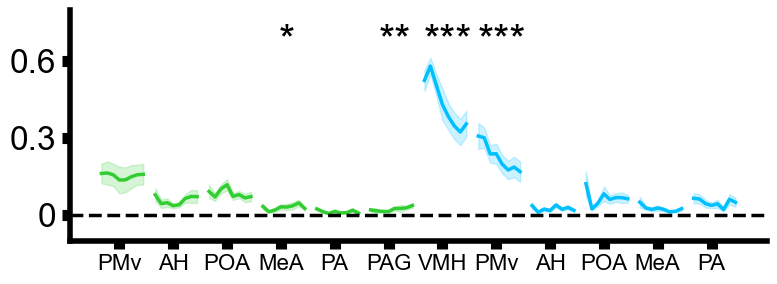

In [ ]:
# Plot correlation changes AGG

from scipy.stats import sem

bar_settings = {
	'color': 'white',
	'linewidth': 2.75,
	'capsize': 2.75,
	'error_kw': {'elinewidth': 2.5, 'capsize': 5, 'capthick': 2.5, 'markeredgewidth': 2}}


# Create a figure for the line plots
fig1, ax1 = plt.subplots(figsize=(9,3))

# Counter for the bar plot positions
bar_counter = 0
factor = 9

ascending_idx = new_idx.copy()

indices = []

for t, roi in enumerate(all_labels):
	table = all_tables[t]
	table = table.dropna(axis=0)
	table = table.reset_index(drop=True)

	# Get unique groups
	groups = table['exp_group'].unique()

	# Color assignment
	if t < 6:
		color='limegreen'
	else:
		color='deepskyblue'

	# Plot
	group = 0
	subset = table[table['exp_group'] == group]
	means = subset.groupby('cross_day')['dependent_variable'].mean()
	errors = subset.groupby('cross_day')['dependent_variable'].apply(sem)
	ax1.plot(means.index.values + t*factor, means.values, color=color, linewidth=2.5)
	ax1.fill_between(means.index.values + t*factor, means.values - errors.values, means.values + errors.values, alpha=0.2, color=color)
	indices.append(t*factor)

# Cleaning
ax1.set_xticks((np.arange(0, (len(constrained_idxs))*factor, factor)+2)+1, all_labels, fontsize=16, fontfamily='Arial')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylim(top=0.8, bottom=-0.1)
ax1.set_yticks([0, 0.3, 0.6])
ax1.set_yticklabels([0, 0.3, 0.6], fontsize=24, fontfamily='Arial');
ax1.set_title('')
ax1.axhline(0, color='black', linewidth=2.5, linestyle='--')

# Adding stars
try:
	for p_value, index in zip(p_values_AGG_corrected, indices):
		# If the p-value is less than 0.05, add a "*" above the line
		if p_value < 0.06:
			if p_value < 0.001:
				marker='***'
			elif p_value < 0.01:
				marker = '**'
			elif p_value < 0.05:
				marker = '*'
			elif p_value < 0.06:
				marker = ''
			plt.text(index+4, 0.6, marker, ha='center', va='bottom', fontsize=30, color='black', fontfamily='Arial')
except ValueError:
	pass

# Save fig1 as an SVG file
# fig1.savefig('.\\figures\\VMH_knockouts_overtime_AGG_nonsocial_behaviors.svg', dpi=300, format='svg')

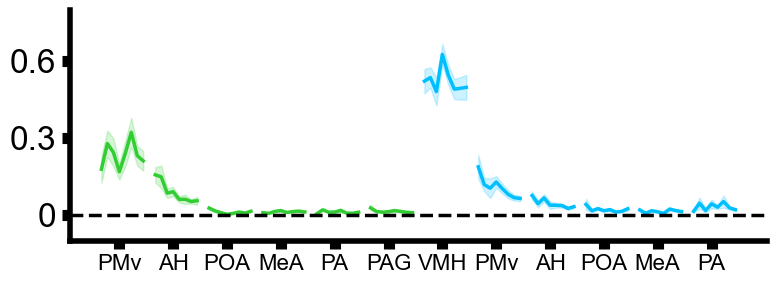

In [ ]:
# Plot correlation changes OBS

# Create a figure for the line plots
fig1, ax1 = plt.subplots(figsize=(9, 3))

# Counter for the bar plot positions
bar_counter = 0
factor = 9

ascending_idx = new_idx.copy()

indices = []

for t, roi in enumerate(all_labels):
	table = all_tables[t]
	table = table.dropna(axis=0)
	table = table.reset_index(drop=True)

	# Get unique groups
	groups = table['exp_group'].unique()

	# Color assignment
	if t < 6:
		color='limegreen'
	else:
		color='deepskyblue'

	# Plot
	group = 1
	subset = table[table['exp_group'] == group]
	means = subset.groupby('cross_day')['dependent_variable'].mean()
	errors = subset.groupby('cross_day')['dependent_variable'].apply(sem)
	ax1.plot(means.index.values + t*factor, means.values, color=color, linewidth=2.5)
	ax1.fill_between(means.index.values + t*factor, means.values - errors.values, means.values + errors.values, alpha=0.2, color=color)
	indices.append(t*factor)

# Cleaning
ax1.set_xticks((np.arange(0, (len(constrained_idxs))*factor, factor)+2)+1, all_labels, fontsize=16, fontfamily='Arial')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.set_ylim(top=0.8, bottom=-0.1)
ax1.set_yticks([0, 0.3, 0.6])
ax1.set_yticklabels([0, 0.3, 0.6], fontsize=24, fontfamily='Arial');
ax1.set_title('')
ax1.axhline(0, color='black', linewidth=2.5, linestyle='--')

# Adding stars
try:
	for p_value, index in zip(p_values_OBS_corrected, indices):
		# If the p-value is less than 0.05, add a "*" above the line
		if p_value < 0.06:
			if p_value < 0.001:
				marker='***'
			elif p_value < 0.01:
				marker = '**'
			elif p_value < 0.05:
				marker = '*'
			elif p_value < 0.06:
				marker = ''
			plt.text(index+4, 0.6, marker, ha='center', va='bottom', fontsize=30, color='black', fontfamily='Arial')
except ValueError:
	pass

# Save fig1 as an SVG file
# fig1.savefig('.\\figures\\VMH_knockouts_overtime_OBS_nonsocial_behaviors.svg', dpi=300, format='svg')

### ARD Regression (Figure 5)

Compute shared and unique variance:

In [8]:
from tqdm import tqdm
from sklearn.linear_model import ARDRegression, LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
import warnings

# Suppress warnings from ARD if it occasionally drops all features in a noisy fold
warnings.filterwarnings("ignore", category=UserWarning)

np.random.seed(42)
constrained_idxs = np.array([16, 8, 14, 13, 17, 3, 7, 9, 11]) # remove PA, sub in BNST I

# Initialize global storage arrays
scores_const = np.zeros((27, 13, len(animals)))
weights_const = np.zeros((len(constrained_idxs), 27, 13, len(animals)))
knockouts_const = np.zeros((len(constrained_idxs), 27, 13, len(animals)))
shared_const = np.zeros((len(constrained_idxs), 27, 13, len(animals))) # NEW: Store shared variance

pbar = tqdm(enumerate(animals), total=len(animals)) 
nperms = 100

for a, animal in pbar:
	pbar.set_description('Processing animal %i' % a)
	
	# Load animal data
	if a <= 11:
		exp = 'aggression'
	elif a <= 20: 
		exp = 'observation'
	else:
		exp = 'nonsocial'

	trial_comps, rois = format4analysis(full_data, animal, exp=exp)
	rois = rois[:-2]
	norm_indices = [i for i, item in enumerate(region_ids) if item in set(rois)]
	trial_comps = np.concatenate(trial_comps, axis=2)
	cluster_comps = grab_cluster_idxs(full_data, animal, exp=exp)
	
	# Create arrays for storage of weights and % drop across epochs
	epoch_scores = np.zeros((trial_comps.shape[2], 13))
	epoch_scores[:] = np.nan
	epoch_weights = np.zeros((len(constrained_idxs), trial_comps.shape[2], 13))
	epoch_weights[:] = np.nan
	epoch_knockouts = epoch_weights.copy()
	epoch_shared = epoch_weights.copy() # NEW: Epoch-level shared container
	
	for e in np.arange(trial_comps.shape[-1]):
		epoch = trial_comps[:, :, e]
		for region_idx, orig_idx in enumerate(norm_indices):
			if orig_idx != 12: # only VMH
				continue
			
			# Format y
			y = epoch[:, region_idx]
			y = y[~np.isnan(y)].reshape(-1,1)
			if np.isnan(y).all():
				continue

			# Format X
			X = epoch[:, constrained_idxs]
			orig_X_shape = X.shape
			X = X[:, ~np.all(np.isnan(X), axis=0)]
			X = X[~np.any(np.isnan(X), axis=1)]
			new_X_shape = X.shape
			if new_X_shape[1] < len(constrained_idxs): # if a region is missing
				continue
			
			# Index into clusters
			for c in np.arange(cluster_comps[e].shape[1]):
				cluster_indices = np.where(cluster_comps[e][:, c]==1)[0]
				if len(cluster_indices) > 80:
					X_hat = X[cluster_indices, :]
					y_hat = y[cluster_indices, :].ravel() # Scikit-learn prefers 1D y
					
					try:
						# --- 1. K-Fold Cross Validation Setup ---
						kf = KFold(n_splits=3, shuffle=True, random_state=42)
						y_pred_full = np.zeros_like(y_hat)
						models = [] 
						
						# Train full ARD models across folds
						for train_idx, test_idx in kf.split(X_hat):
							model = ARDRegression()
							model.fit(X_hat[train_idx], y_hat[train_idx])
							y_pred_full[test_idx] = model.predict(X_hat[test_idx])
							models.append((model, train_idx, test_idx))
							
						# True Out-of-Sample Full R-squared
						best_score = max(r2_score(y_hat, y_pred_full), 0)
						epoch_scores[e, c] = best_score
						
						# Store average weights across the 5 folds
						avg_weights = np.mean([m[0].coef_ for m in models], axis=0)
						epoch_weights[:, e, c] = avg_weights
						
						# --- 2. Calculate Unique & Marginal Variance ---
						knockouts = np.zeros((X.shape[1]))
						shared_vars = np.zeros((X.shape[1]))
						
						for knockout_idx in np.arange(X.shape[1]):
							
							# A. Out-of-Sample Knockout (Unique Variance)
							avg_ko = []
							for n in np.arange(nperms):
								y_pred_ko = np.zeros_like(y_hat)
								for model, train_idx, test_idx in models:
									X_test_shuffled = X_hat[test_idx].copy()
									np.random.shuffle(X_test_shuffled[:, knockout_idx])
									y_pred_ko[test_idx] = model.predict(X_test_shuffled)
									
								ko_score = max(r2_score(y_hat, y_pred_ko), 0)
								avg_ko.append(ko_score)
								
							ko_score_mean = np.mean(avg_ko) 
							knockout_score_difference = max(best_score - ko_score_mean, 0)
							knockouts[knockout_idx] = knockout_score_difference
							
							# B. Marginal Model (Just this single region)
							y_pred_marg = np.zeros_like(y_hat)
							X_marg = X_hat[:, knockout_idx].reshape(-1, 1)
							
							for train_idx, test_idx in kf.split(X_marg):
								# OLS is perfectly fine for a single feature (no multicollinearity possible)
								marg_model = LinearRegression() 
								marg_model.fit(X_marg[train_idx], y_hat[train_idx])
								y_pred_marg[test_idx] = marg_model.predict(X_marg[test_idx])
								
							marginal_score = max(r2_score(y_hat, y_pred_marg), 0)
							
							# C. Shared Variance by Region
							shared_region = max(marginal_score - knockout_score_difference, 0)
							shared_vars[knockout_idx] = shared_region
							
						epoch_knockouts[:, e, c] = knockouts
						epoch_shared[:, e, c] = shared_vars
						
					except ValueError:
						continue

	# Store in global containers
	scores_const[:, :, a] = epoch_scores
	weights_const[:, :, :, a] = epoch_weights
	knockouts_const[:, :, :, a] = epoch_knockouts
	shared_const[:, :, :, a] = epoch_shared

Processing animal 0:   0%|          | 0/29 [00:00<?, ?it/s]

Processing animal 28: 100%|██████████| 29/29 [1:40:59<00:00, 208.93s/it]


Perform stats:

In [9]:
# Gather tables
all_tables = {}
animals2include = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28])
sessions2include = [0, 24]
behaviors = [0,1,2,3,4,6,7,8] 
# behaviors = np.arange(10, 13)
supercluster_kos = np.nanmean(knockouts_const[:, :, behaviors, :], axis=2)
weights2map = np.transpose(supercluster_kos, [1,0,2])
all_labels = ['PMv', 'AH', 'PAG', 'VMH', 'PMv', 'vLS', 'BNST', 'AH', 'MeA']


all_tables = []
for r, roi in enumerate(constrained_idxs):
	table = pd.DataFrame(columns=['cross_day', 'cross_session', 'within_day', 'subject', 'dependent_variable'])
	for animal in np.arange((len(np.concatenate([agg_animals, obs_animals, non_animals]))))[animals2include]:
		sample = weights2map[sessions2include[0]:sessions2include[1], r, animal]
		cross_day_info = np.repeat(np.arange(8), 3)[sessions2include[0]:sessions2include[1]].astype(float)
		within_day_info = np.tile(np.arange(3), 8)[sessions2include[0]:sessions2include[1]].astype(float)
		session_info = np.arange(24)[sessions2include[0]:sessions2include[1]].astype(float)
		subject_info = np.repeat(animal, 24)[sessions2include[0]:sessions2include[1]]
		if animal<=11:
			group_info = np.repeat(0, 24)[sessions2include[0]:sessions2include[1]]
		elif animal<=20:
			group_info = np.repeat(1, 24)[sessions2include[0]:sessions2include[1]]
		else:
			group_info = np.repeat(2, 24)[sessions2include[0]:sessions2include[1]]
		table = pd.concat([table, pd.DataFrame({'cross_day': cross_day_info, 'cross_session': session_info, 'within_day': within_day_info, 'subject': subject_info, 'exp_group': group_info, 'dependent_variable': sample})])
	all_tables.append(table)

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_7980\466095786.py:7: RuntimeWarning: Mean of empty slice
  supercluster_kos = np.nanmean(knockouts_const[:, :, behaviors, :], axis=2)


In [13]:
# Interaction analysis

from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM
from sklearn.preprocessing import StandardScaler

def run_interaction_analysis(data_exp, data_non, roi_labels):
    """
    Performs LME with Time x Group interaction to subtract adaptation.
    Returns: Interaction T-values and FDR-corrected P-values.
    """
    int_p_vals = []
    int_t_vals = []

    for r in range(len(roi_labels)):
        # Data for this ROI
        exp_roi = data_exp[r] # (Subjects, Timepoints)
        non_roi = data_non[r] 

        # Build DataFrame for Experimental Group
        df_exp = pd.DataFrame({
            'Value': exp_roi.flatten(),
            'Subject': np.repeat(np.arange(exp_roi.shape[0]), exp_roi.shape[1]),
            'Time': np.tile(np.arange(exp_roi.shape[1]), exp_roi.shape[0]),
            'Group': 1 # Experimental Group
        })
        
        # Build DataFrame for Control Group (NON)
        df_non = pd.DataFrame({
            'Value': non_roi.flatten(),
            'Subject': np.repeat(np.arange(non_roi.shape[0]) + 100, non_roi.shape[1]), # Offset IDs
            'Time': np.tile(np.arange(non_roi.shape[1]), non_roi.shape[0]),
            'Group': 0 # Control Group
        })

        df_combined = pd.concat([df_exp, df_non]).dropna()
        
        # Standardize Time to center the intercept
        df_combined['Time_scaled'] = (df_combined['Time'] - df_combined['Time'].mean()) / df_combined['Time'].std()

        try:
            # Model: Fixed effects for Time, Group, and their Interaction
            # Random intercept for each Subject
            model = smf.mixedlm("Value ~ Time_scaled * Group", df_combined, groups=df_combined["Subject"])
            res = model.fit(method='bfgs', reml=False)

            # Extract the Interaction Term (Time_scaled:Group)
            int_p_vals.append(res.pvalues['Time_scaled:Group'])
            int_t_vals.append(res.tvalues['Time_scaled:Group'])
        except:
            int_p_vals.append(1.0)
            int_t_vals.append(0.0)

    # Correct for multiple comparisons across ROIs
    corrected_p = multipletests(int_p_vals, method='fdr_tsbh')[1]
    return np.array(int_t_vals), np.array(corrected_p)

# --- EXECUTION ---

# 0. Prepare data for interaction analysis
new_idx = np.arange(len(constrained_idxs))
norm_idx = new_idx.copy()
all_labels = [x.replace(' (E)', '').replace(' (I)', '').replace(' (DA)','') for x in np.array(region_ids)[constrained_idxs]]
mean_func = np.nanmean

agg_decouples_daily = [mean_func(weights2map[i:i+3, :, :12], axis=0).reshape(len(constrained_idxs), 12, 1) for i in np.arange(0, 27, 3)]
agg_decouples_daily = np.concatenate(agg_decouples_daily[:-1], axis=2)

obs_decouples_daily = [mean_func(weights2map[i:i+3, :, 12:21], axis=0).reshape(len(constrained_idxs), 9, 1) for i in np.arange(0, 27, 3)]
obs_decouples_daily = np.concatenate(obs_decouples_daily[:-1], axis=2)

non_decouples_daily = [mean_func(weights2map[i:i+3, :, 21:], axis=0).reshape(len(constrained_idxs), 8, 1) for i in np.arange(0, 27, 3)]
non_decouples_daily = np.concatenate(non_decouples_daily[:-1], axis=2)

agg_decouples = np.nanmean(agg_decouples_daily.reshape(len(constrained_idxs), 12, 4, 2), axis=3)
obs_decouples = np.nanmean(obs_decouples_daily.reshape(len(constrained_idxs), 9, 4, 2), axis=3)
non_decouples = np.nanmean(non_decouples_daily.reshape(len(constrained_idxs), 8, 4, 2), axis=3)

supercluster_shared = np.nanmean(shared_const[:, :, behaviors, :], axis=2)
weights2map_shared = np.transpose(supercluster_shared, [1,0,2])

agg_shared_daily = [mean_func(weights2map_shared[i:i+3, :, :12], axis=0).reshape(len(constrained_idxs), 12, 1) for i in np.arange(0, 27, 3)]
agg_shared_daily = np.concatenate(agg_shared_daily[:-1], axis=2)

obs_shared_daily = [mean_func(weights2map_shared[i:i+3, :, 12:21], axis=0).reshape(len(constrained_idxs), 9, 1) for i in np.arange(0, 27, 3)]
obs_shared_daily = np.concatenate(obs_shared_daily[:-1], axis=2)

non_shared_daily = [mean_func(weights2map_shared[i:i+3, :, 21:], axis=0).reshape(len(constrained_idxs), 8, 1) for i in np.arange(0, 27, 3)]
non_shared_daily = np.concatenate(non_shared_daily[:-1], axis=2)

agg_shared_binned = np.nanmean(agg_shared_daily.reshape(len(constrained_idxs), 12, 4, 2), axis=3)
obs_shared_binned = np.nanmean(obs_shared_daily.reshape(len(constrained_idxs), 9, 4, 2), axis=3)
non_shared_binned = np.nanmean(non_shared_daily.reshape(len(constrained_idxs), 8, 4, 2), axis=3)

# 1. Unique Variance Interactions
print("Running Interaction Stats for Unique Variance...")
t_agg_u_int, p_agg_u_int = run_interaction_analysis(agg_decouples, non_decouples, all_labels)
t_obs_u_int, p_obs_u_int = run_interaction_analysis(obs_decouples, non_decouples, all_labels)

# 2. Shared Variance Interactions
print("Running Interaction Stats for Shared Variance...")
t_agg_s_int, p_agg_s_int = run_interaction_analysis(agg_shared_binned, non_shared_binned, all_labels)
t_obs_s_int, p_obs_s_int = run_interaction_analysis(obs_shared_binned, non_shared_binned, all_labels)

# --- Mapping results back to plotting variables ---
# These will now represent "Social Significance" above baseline adaptation
p_values_AGG_corrected = p_agg_u_int
p_values_OBS_corrected = p_obs_u_int
p_values_AGG_corrected_shared = p_agg_s_int
p_values_OBS_corrected_shared = p_obs_s_int

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_7980\2633438857.py:67: RuntimeWarning: Mean of empty slice
  agg_decouples_daily = [mean_func(weights2map[i:i+3, :, :12], axis=0).reshape(len(constrained_idxs), 12, 1) for i in np.arange(0, 27, 3)]
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_7980\2633438857.py:76: RuntimeWarning: Mean of empty slice
  agg_decouples = np.nanmean(agg_decouples_daily.reshape(len(constrained_idxs), 12, 4, 2), axis=3)
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_7980\2633438857.py:80: RuntimeWarning: Mean of empty slice
  supercluster_shared = np.nanmean(shared_const[:, :, behaviors, :], axis=2)
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_7980\2633438857.py:83: RuntimeWarning: Mean of empty slice
  agg_shared_daily = [mean_func(weights2map_shared[i:i+3, :, :12], axis=0).reshape(len(constrained_idxs), 12, 1) for i in np.arange(0, 27, 3)]
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_7980\2633438857.py:92: RuntimeWarning: Mean of empty slice
  

Running Interaction Stats for Unique Variance...
Running Interaction Stats for Shared Variance...


Plot - training period:

In [ ]:
# Permutation test for interaction significance

def permutation_mean_test(data1, data2, n_perms=10000, seed=42):
    """
    Two-sided permutation test on the difference of means.
    """
    rng      = np.random.default_rng(seed)
    obs_diff = np.abs(np.mean(data1) - np.mean(data2))
    pooled   = np.concatenate([data1, data2])
    n1       = len(data1)
    null     = np.array([
        np.abs(np.mean(perm[:n1]) - np.mean(perm[n1:]))
        for perm in [rng.permutation(pooled) for _ in range(n_perms)]
    ])
    return np.mean(null >= obs_diff)

def test_normality_and_compare(data1, data2, n_perms=10000):
    return permutation_mean_test(data1, data2, n_perms=n_perms)

# Collect p-values for multiple comparisons
all_agg_pvals = []
all_obs_pvals = []
all_agg_data = []
all_obs_data = []
nbehaviors = 8
days = 2
days = days * 3

# Reshape the data to have dimensions: (ROIs, Timepoints, Subjects) for each group
agg_early = knockouts_const[:, 0:days, behaviors, 0:12].reshape(len(all_labels), days*nbehaviors, 12)
obs_early = knockouts_const[:, 0:days, behaviors, 12:21].reshape(len(all_labels), days*nbehaviors, 9)
non_early = knockouts_const[:, 0:days, behaviors, 21:].reshape(len(all_labels), days*nbehaviors, 8)

agg_late = knockouts_const[:, -3-days:-3, behaviors, 0:12].reshape(len(all_labels), days*nbehaviors, 12)
obs_late = knockouts_const[:, -3-days:-3, behaviors, 12:21].reshape(len(all_labels), days*nbehaviors, 9)
non_late = knockouts_const[:, -3-days:-3, behaviors, 21:].reshape(len(all_labels), days*nbehaviors, 8)

# Initialize containers for p-values and data
all_agg_pvals = []
all_obs_pvals = []
all_non_pvals = []

# List to iterate through groups
# Format: (data_early_source, data_late_source, pval_list, group_label)
comparison_groups = [
    (agg_early, agg_late, all_agg_pvals, "AGG"),
    (obs_early, obs_late, all_obs_pvals, "OBS"),
    (non_early, non_late, all_non_pvals, "NON")
]

# --- 1. Clean Data and Perform Statistics ---
for r, roi_name in enumerate(all_labels):
    for early_src, late_src, pval_list, label in comparison_groups:
        
        # Flatten and drop NaNs
        early_data = early_src[r].flatten()
        early_clean = early_data[~np.isnan(early_data)]
        
        late_data = late_src[r].flatten()
        late_clean = late_data[~np.isnan(late_data)]
        
        # Check if we have sufficient data to run the test
        if len(early_clean) > 2 and len(late_clean) > 2:
            # Use your standard normality-checked comparison function
            p_val = test_normality_and_compare(
                early_clean, 
                late_clean, 
            )
            pval_list.append(p_val)
        else:
            print(f"Warning: Insufficient data for {roi_name} in {label} group.")
            pval_list.append(np.nan)

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_7980\2148016291.py:56: RuntimeWarning: Mean of empty slice
  animal_day_values = np.nanmean(day_data, axis=(0, 1))


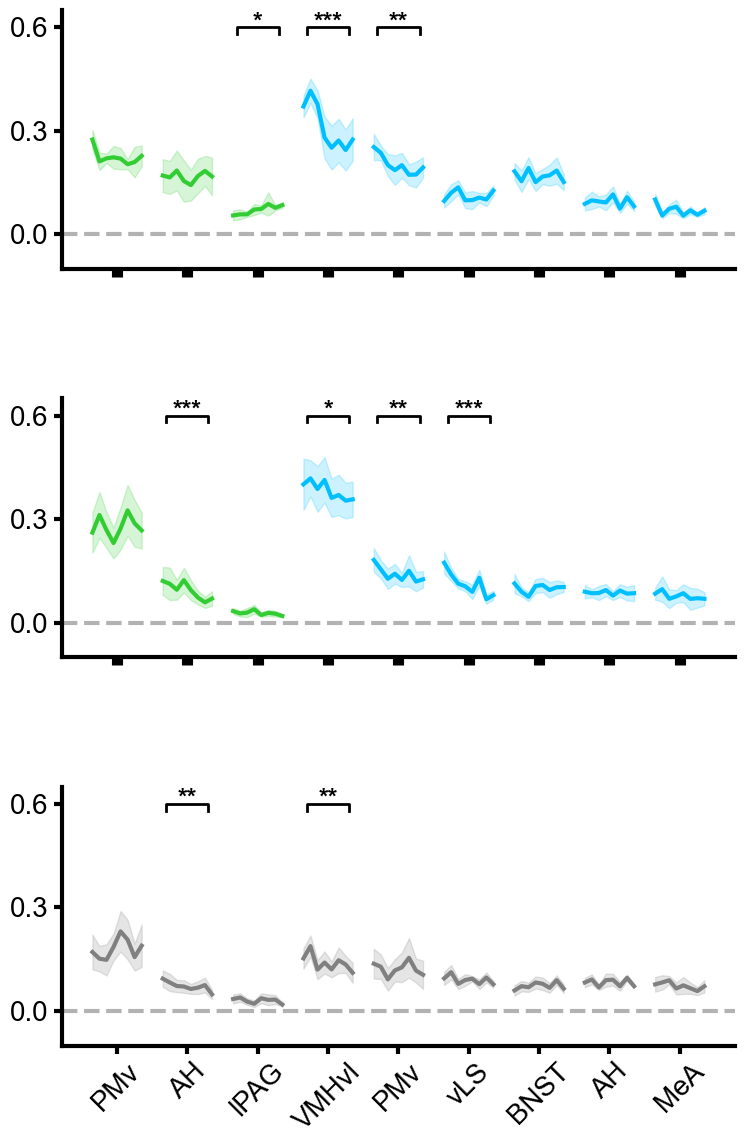

In [189]:
from statsmodels.stats.multitest import multipletests

# ==========================================
# CENTRAL DESIGN CONTROL PANEL
# ==========================================
FS_TITLE = 16        # Plot titles
FS_LABEL_X = 20      # ROI labels at the bottom
FS_TICKS_X = 20      # X-axis tick numbers (if used)
FS_TICKS_Y = 20      # Y-axis tick labels (0, 0.3, 0.6)
FS_STAR = 18         # Significance stars
LW_LINE = 3        # Main sparkline thickness
LW_BRACKET = 2     # Significance bracket thickness
LW_AXIS = 3        # Spine/Axis line thickness
LW_H_LINE = 3      # Horizontal dashed line (y=0)
BRACKET_Y = 0.6     # Vertical height of the bracket
BRACKET_H = 0.02     # Height of the bracket "ticks"
SPACING_H = 0.5      # Vertical space between subplots
# ==========================================

# --- 2. Multiple Comparisons Correction (FDR) ---
p_agg_corrected = multipletests(np.nan_to_num(all_agg_pvals, nan=1.0), method='fdr_bh')[1]
p_obs_corrected = multipletests(np.nan_to_num(all_obs_pvals, nan=1.0), method='fdr_bh')[1]
p_non_corrected = multipletests(np.nan_to_num(all_non_pvals, nan=1.0), method='fdr_bh')[1]

# --- 3. Parameters & Figure Setup ---
n_days = 8
sess_per_day = 3
factor = 10 
new_labels = [x.replace('VMH', 'VMHvl').replace('PAG', 'lPAG') for x in all_labels]

fig, (ax_agg, ax_obs, ax_non) = plt.subplots(3, 1, figsize=(8, 12), sharex=True, sharey=True)
plt.rcParams['font.family'] = 'Arial'

def get_sig_marker(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return None

group_configs = [
    (ax_agg, slice(0, 12), 'AGG', p_agg_corrected, False),
    (ax_obs, slice(12, 21), 'OBS', p_obs_corrected, False),
    (ax_non, slice(21, 29), 'NON', p_non_corrected, True) 
]

for ax, group_slice, group_label, corrected_ps, is_non in group_configs:

    for r, roi_label in enumerate(all_labels):
        daily_means = []
        daily_sems = []
        
        for day in range(n_days):
            start = day * sess_per_day
            end = start + sess_per_day
            day_data = knockouts_const[r, start:end, behaviors, group_slice]
            animal_day_values = np.nanmean(day_data, axis=(0, 1)) 
            daily_means.append(np.nanmean(animal_day_values))
            daily_sems.append(stats.sem(animal_day_values, nan_policy='omit'))
        
        x_positions = np.arange(n_days) + (r * factor)
        means = np.array(daily_means)
        errs = np.array(daily_sems)
        
        color = 'grey' if is_non else ('limegreen' if r < 3 else 'deepskyblue')

        ax.plot(x_positions, means, color=color, linewidth=LW_LINE)
        ax.fill_between(x_positions, means - errs, means + errs, alpha=0.2, color=color)
        
        # --- Significance Brackets ---
        marker = get_sig_marker(corrected_ps[r])
        if marker:
            x_start = 0.5 + (r * factor)
            x_end = 6.5 + (r * factor)
            
            # Bracket Line
            ax.plot([x_start, x_start, x_end, x_end], 
                    [BRACKET_Y - BRACKET_H, BRACKET_Y, BRACKET_Y, BRACKET_Y - BRACKET_H], 
                    color='black', lw=LW_BRACKET)
            
            # Star text
            ax.text((x_start + x_end)/2, BRACKET_Y - 0.02, marker, 
                    ha='center', va='bottom', fontsize=FS_STAR, 
                    fontweight='bold', fontfamily='Arial')

    # General Axis Formatting
    ax.set_ylim(-0.1, 0.65)
    ax.set_yticks([0, 0.3, 0.6])
    
    # Ensure Y-ticks and labels are visible and correctly styled
    ax.tick_params(axis='y', which='both', left=True, labelleft=True, width=LW_AXIS)
    for label in ax.get_yticklabels():
        label.set_fontname('Arial')
        label.set_fontsize(FS_TICKS_Y)

    # Spine Formatting
    ax.axhline(0, color='black', linestyle='--', linewidth=LW_H_LINE, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(LW_AXIS)
    ax.spines['bottom'].set_linewidth(LW_AXIS)

# Formatting for X-axis (NON plot)
tick_pos = np.arange(0, len(all_labels) * factor, factor) + 3.5
ax_non.set_xticks(tick_pos)
ax_non.set_xticklabels(new_labels, fontsize=FS_LABEL_X, rotation=45, fontfamily='Arial')
ax_non.tick_params(axis='x', which='both', bottom=True, labelbottom=True, width=LW_AXIS)

# Final spacing cleanup
plt.tight_layout()
plt.subplots_adjust(hspace=SPACING_H) 
# plt.show()

plt.savefig('.\\figures\\fig5\\VMH_variance_overtime_AGG_OBS_NON_comparison.svg', dpi=300, format='svg')

In [190]:
# ── Stats table ───────────────────────────────────────────────────────────────
print(f'\n{"="*90}')
print(f'Early vs Late unique variance — permutation test on mean difference')
print(f'Early: sessions 0–{days-1} | Late: sessions -{days+3} to -3')
print(f'Correction: FDR-BH within each group across {len(all_labels)} regions')
print(f'{"="*90}')
print(f'{"Group":<6} {"Region":<10} '
      f'{"mean_early":>12} {"mean_late":>12} '
      f'{"n_early":>8} {"n_late":>8} '
      f'{"p_raw":>10} {"p_fdr":>10} {"Sig":>5}')
print(f'{"─"*90}')

for group_label, pvals_raw, pvals_corr, early_src, late_src in [
    ('AGG', all_agg_pvals, p_agg_corrected, agg_early, agg_late),
    ('OBS', all_obs_pvals, p_obs_corrected, obs_early, obs_late),
    ('NON', all_non_pvals, p_non_corrected, non_early, non_late),
]:
    for r, roi in enumerate(all_labels):
        early_d = early_src[r].flatten()
        early_d = early_d[~np.isnan(early_d)]
        late_d  = late_src[r].flatten()
        late_d  = late_d[~np.isnan(late_d)]

        p_raw = pvals_raw[r]
        p_fdr = pvals_corr[r]
        sig   = get_sig(p_fdr) if not np.isnan(p_fdr) else 'n/a'

        def _f(p): return f'{p:.4f}' if not np.isnan(p) else '     n/a'

        print(f'{group_label:<6} {all_labels[r]:<10} '
              f'{np.nanmean(early_d):>12.4f} {np.nanmean(late_d):>12.4f} '
              f'{len(early_d):>8} {len(late_d):>8} '
              f'{_f(p_raw):>10} {_f(p_fdr):>10} {sig:>5}')

    print(f'{"─"*90}')

print(f'{"="*90}')


Early vs Late unique variance — permutation test on mean difference
Early: sessions 0–5 | Late: sessions -9 to -3
Correction: FDR-BH within each group across 9 regions
Group  Region       mean_early    mean_late  n_early   n_late      p_raw      p_fdr   Sig
──────────────────────────────────────────────────────────────────────────────────────────
AGG    PMv              0.2434       0.2197      287      282     0.2692     0.4846      
AGG    AH               0.1631       0.1699      287      282     0.7261     0.8796      
AGG    PAG              0.0562       0.0803      287      282     0.0051     0.0153     *
AGG    VMH              0.3959       0.2584      287      282     0.0000     0.0000   ***
AGG    PMv              0.2455       0.1857      287      282     0.0022     0.0099    **
AGG    vLS              0.1103       0.1137      287      282     0.8167     0.8796      
AGG    BNST             0.1708       0.1733      287      282     0.8796     0.8796      
AGG    AH           

Plot - hard fight:

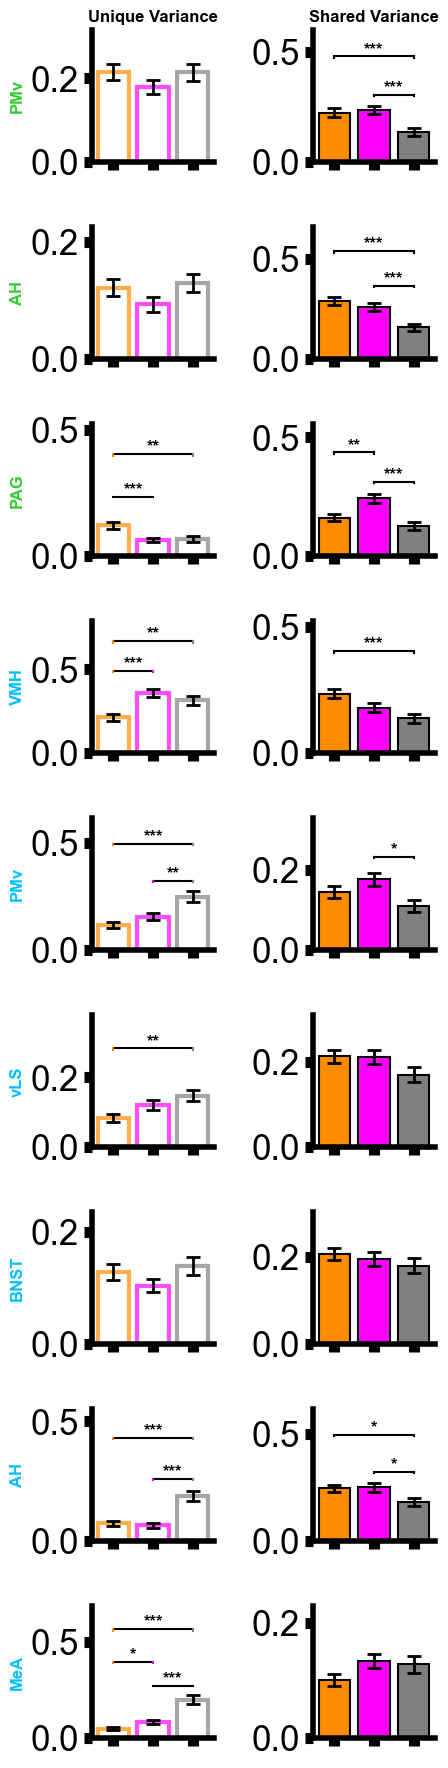

In [ ]:
from statsmodels.stats.multitest import multipletests
import matplotlib.gridspec as gridspec

# ── groups_bar ────────────────────────────────────────────────────────────────
groups_bar = ['AGG', 'OBS', 'NON']

# ── colors_shared (needed for shared variance bars) ───────────────────────────
colors_shared = ['darkorange', 'magenta', 'gray']

# ── add stats helpers      ────────────────────────────────────────────────────
def add_comparison_bracket(ax, x1, x2, y, p_val, mean1, mean2, colors):
    """
    Draw a significance bracket between two bar positions.
    Colors: [color_left, color_right] for the vertical tick marks.
    """
    if p_val < 0.001:   sig = '***'
    elif p_val < 0.01:  sig = '**'
    elif p_val < 0.05:  sig = '*'
    else:               return   # don't draw ns brackets

    h = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02

    # horizontal bar
    ax.plot([x1, x2], [y, y], color='black', linewidth=1.5)
    # left tick
    ax.plot([x1, x1], [y - h, y], color=colors[0], linewidth=1.5)
    # right tick
    ax.plot([x2, x2], [y - h, y], color=colors[1], linewidth=1.5)
    # significance text
    ax.text((x1 + x2) / 2, y, sig,
            ha='center', va='bottom',
            fontsize=12, fontweight='bold', fontfamily='Arial')

def get_sig(p):
    if np.isnan(p):
        return ''
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

# ── stat methods     ──────────────────────────────────────────────────────────
from scipy.stats import kruskal, f_oneway

def permutation_mean_test(data1, data2, n_perms=10000, seed=42):
    """
    Two-sided permutation test on the difference of means.
    """
    rng      = np.random.default_rng(seed)
    obs_diff = np.abs(np.mean(data1) - np.mean(data2))
    pooled   = np.concatenate([data1, data2])
    n1       = len(data1)
    null     = np.array([
        np.abs(np.mean(perm[:n1]) - np.mean(perm[n1:]))
        for perm in [rng.permutation(pooled) for _ in range(n_perms)]
    ])
    return np.mean(null >= obs_diff)

def test_normality_and_compare(data1, data2, n_perms=10000):
    return permutation_mean_test(data1, data2, n_perms=n_perms)

def perform_posthoc_tests(agg_data, obs_data, non_data, roi_name=''):
    """
    Omnibus test first, then pairwise only if omnibus significant.
    """
    # ── Omnibus ───────────────────────────────────────────────────────────────
    try:
        _, p_norm_a = shapiro(agg_data[:5000])
        _, p_norm_b = shapiro(obs_data[:5000])
        _, p_norm_c = shapiro(non_data[:5000])
        if p_norm_a > 0.05 and p_norm_b > 0.05 and p_norm_c > 0.05:
            _, p_omni = f_oneway(agg_data, obs_data, non_data)
            omni_test = 'ANOVA'
        else:
            _, p_omni = kruskal(agg_data, obs_data, non_data)
            omni_test = 'KW'
    except Exception:
        p_omni, omni_test = 1.0, 'failed'

    # ── Gate: skip post-hoc if omnibus not significant ────────────────────────
    if p_omni >= 0.05:
        return {
            'AGG_OBS': 1.0,
            'AGG_NON': 1.0,
            'OBS_NON': 1.0,
            'omnibus_p': p_omni,
            'omnibus_test': omni_test,
        }

    # ── Pairwise with FDR ─────────────────────────────────────────────────────
    pairs = {
        'AGG_OBS': (agg_data, obs_data),
        'AGG_NON': (agg_data, non_data),
        'OBS_NON': (obs_data, non_data),
    }
    raw_p = {}
    for key, (a, b) in pairs.items():
        if len(a) >= 3 and len(b) >= 3:
            raw_p[key] = test_normality_and_compare(a, b)
        else:
            raw_p[key] = np.nan

    valid_keys = [k for k, p in raw_p.items() if not np.isnan(p)]
    if valid_keys:
        _, corr, _, _ = multipletests(
            [raw_p[k] for k in valid_keys], method='fdr_bh')
        corrected = {k: c for k, c in zip(valid_keys, corr)}
    else:
        corrected = {}

    result = {k: corrected.get(k, raw_p[k]) for k in pairs}
    result['omnibus_p']    = p_omni
    result['omnibus_test'] = omni_test
    return result

# --- 1. Slicing the Data ---
behaviors = [0,1,2,3,4,6,7,8] # social behaviors

# Isolate Unique Variance (Knockouts)
agg_ko = knockouts_const[:, -3:, behaviors, 0:12].reshape(len(all_labels), len(behaviors)*3, 12) 
obs_ko = knockouts_const[:, -3:, behaviors, 12:21].reshape(len(all_labels), len(behaviors)*3, 9)
non_ko = knockouts_const[:, -3:, behaviors, 21:].reshape(len(all_labels), len(behaviors)*3, 8)

# Isolate Shared Variance (from ARD modeling output)
agg_sh = shared_const[:, -3:, behaviors, 0:12].reshape(len(all_labels), len(behaviors)*3, 12) 
obs_sh = shared_const[:, -3:, behaviors, 12:21].reshape(len(all_labels), len(behaviors)*3, 9)
non_sh = shared_const[:, -3:, behaviors, 21:].reshape(len(all_labels), len(behaviors)*3, 8)

# Isolate Total Variance (R-squared from the full model)
agg_r2 = scores_const[-3:, behaviors, 0:12].reshape(len(behaviors)*3, 12)
obs_r2 = scores_const[-3:, behaviors, 12:21].reshape(len(behaviors)*3, 9)
non_r2 = scores_const[-3:, behaviors, 21:].reshape(len(behaviors)*3, 8)

# --- 2. Calculate Global Shared Variance (for the top summary plot) ---
agg_sum_unique = np.nansum(agg_ko, axis=0)
obs_sum_unique = np.nansum(obs_ko, axis=0)
non_sum_unique = np.nansum(non_ko, axis=0)

agg_shared = np.clip(agg_r2 - agg_sum_unique, a_min=0, a_max=None)
obs_shared = np.clip(obs_r2 - obs_sum_unique, a_min=0, a_max=None)
non_shared = np.clip(non_r2 - non_sum_unique, a_min=0, a_max=None)

# --- 3. Figure Setup ---
factor = 1.0
# Widen figure slightly to accommodate the 3rd column
fig = plt.figure(figsize=(5, (len(all_labels) + 1) * 2 * factor))
# 2 columns now: Unique Bar, Shared var
gs = gridspec.GridSpec(len(all_labels) + 1, 2, width_ratios=[1.0, 1.0], figure=fig)

plt.rcParams['font.family'] = 'Arial'
lw = 2

# --- 4. Plot Region Distributions, Unique, and Shared Bars ---
axes = []
for i in range(1, len(all_labels) + 1): 
	# Add 2 subplots per row now
	axes.append([fig.add_subplot(gs[i, 0]), fig.add_subplot(gs[i, 1])])
axes = np.array(axes)

for r, roi in enumerate(all_labels):
	try: 
		# Clean Unique Data
		agg_roi_activity = agg_ko[r].flatten()[np.isnan(agg_ko[r].flatten()) == False]
		obs_roi_activity = obs_ko[r].flatten()[np.isnan(obs_ko[r].flatten()) == False]
		non_roi_activity = non_ko[r].flatten()[np.isnan(non_ko[r].flatten()) == False]
		
		# Clean Shared Data
		agg_roi_shared = agg_sh[r].flatten()[np.isnan(agg_sh[r].flatten()) == False]
		obs_roi_shared = obs_sh[r].flatten()[np.isnan(obs_sh[r].flatten()) == False]
		non_roi_shared = non_sh[r].flatten()[np.isnan(non_sh[r].flatten()) == False]
		
		agg_mean = np.nanmean(agg_roi_activity)
		obs_mean = np.nanmean(obs_roi_activity)
		non_mean = np.nanmean(non_roi_activity)

		# --- LEFT COLUMN: Bar plots (Unique Variance) ---
		ax_bar_u = axes[r, 0]
		
		means_u = [agg_mean, obs_mean, non_mean]
		sems_u = [stats.sem(agg_roi_activity), stats.sem(obs_roi_activity), stats.sem(non_roi_activity)]
		colors_bar = ['darkorange', 'magenta', 'grey']
		
		ax_bar_u.bar(groups_bar, means_u, yerr=sems_u, capsize=5, 
					 color='white', alpha=0.7, edgecolor=colors_bar, linewidth=3,
					 error_kw={'elinewidth': 2, 'capthick': 2})
	
		ax_bar_u.set_xticks(range(len(groups_bar)))
		ax_bar_u.set_xticklabels(groups_bar, fontfamily='Arial')
		ax_bar_u.tick_params(axis='both', which='both', labelbottom=True, labelleft=True, bottom=True, left=True)
		ax_bar_u.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}'))
		
		# Only add title to the top row of the inner plots
		if r == 0: ax_bar_u.set_title("Unique Variance", fontfamily='Arial', fontsize=12, fontweight='bold')
		
		for label in ax_bar_u.get_yticklabels():
			label.set_fontfamily('Arial')
		
		# Post-hoc tests for Unique
		pairwise_p_u = perform_posthoc_tests(agg_roi_activity, obs_roi_activity, non_roi_activity, roi)
		
		max_h_u = max(means_u) + max(sems_u)
		bh_u = max_h_u * 0.05
		high_u = max_h_u
		
		if pairwise_p_u['OBS_NON'] < 0.05:
			y_pos = max_h_u + 0.05
			add_comparison_bracket(ax_bar_u, 1, 2, y_pos, pairwise_p_u['OBS_NON'], means_u[1], means_u[2], ['magenta', 'grey'])
			max_h_u, high_u = y_pos + bh_u + 0.01, max(high_u, y_pos + 0.02)
		if pairwise_p_u['AGG_OBS'] < 0.05:
			y_pos = max_h_u + 0.1
			add_comparison_bracket(ax_bar_u, 0, 1, y_pos, pairwise_p_u['AGG_OBS'], means_u[0], means_u[1], ['darkorange', 'magenta'])
			max_h_u, high_u = y_pos + bh_u + 0.01, max(high_u, y_pos + 0.02)
		if pairwise_p_u['AGG_NON'] < 0.05:
			y_pos = max_h_u + 0.15
			add_comparison_bracket(ax_bar_u, 0, 2, y_pos, pairwise_p_u['AGG_NON'], means_u[0], means_u[2], ['darkorange', 'grey'])
			high_u = max(high_u, y_pos + 0.02)
		
		ax_bar_u.set_ylim(0, high_u + 0.1)
		color = 'limegreen' if r < 3 else 'deepskyblue'
		ax_bar_u.set_ylabel(roi, color=color, fontfamily='Arial', fontweight='bold', fontsize=12)
		ax_bar_u.set_xticklabels([])


		# --- RIGHT COLUMN: Bar plots (Shared Variance) ---
		ax_bar_s = axes[r, 1]
		
		means_s = [np.nanmean(agg_roi_shared), np.nanmean(obs_roi_shared), np.nanmean(non_roi_shared)]
		sems_s = [stats.sem(agg_roi_shared), stats.sem(obs_roi_shared), stats.sem(non_roi_shared)]
		
		# Use solid fill to distinguish Shared from the white-filled Unique bars
		ax_bar_s.bar(groups_bar, means_s, yerr=sems_s, capsize=5, 
					 color=colors_shared, edgecolor='black', linewidth=1.5,
					 error_kw={'elinewidth': 2, 'capthick': 2})
	
		ax_bar_s.set_xticks(range(len(groups_bar)))
		ax_bar_s.set_xticklabels(groups_bar, fontfamily='Arial')
		ax_bar_s.tick_params(axis='both', which='both', labelbottom=True, labelleft=True, bottom=True, left=True)
		ax_bar_s.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:.1f}'))
		
		if r == 0: ax_bar_s.set_title("Shared Variance", fontfamily='Arial', fontsize=12, fontweight='bold')

		for label in ax_bar_s.get_yticklabels():
			label.set_fontfamily('Arial')
			
		# Post-hoc tests for Shared
		pairwise_p_s = perform_posthoc_tests(agg_roi_shared, obs_roi_shared, non_roi_shared, roi)
		
		max_h_s = max(means_s) + max(sems_s)
		bh_s = max_h_s * 0.05
		high_s = max_h_s
		
		# Note: Colors array matching the solid bars
		if pairwise_p_s['OBS_NON'] < 0.05:
			y_pos = max_h_s + 0.05
			add_comparison_bracket(ax_bar_s, 1, 2, y_pos, pairwise_p_s['OBS_NON'], means_s[1], means_s[2], ['black', 'black'])
			max_h_s, high_s = y_pos + bh_s + 0.01, max(high_s, y_pos + 0.02)
		if pairwise_p_s['AGG_OBS'] < 0.05:
			y_pos = max_h_s + 0.1
			add_comparison_bracket(ax_bar_s, 0, 1, y_pos, pairwise_p_s['AGG_OBS'], means_s[0], means_s[1], ['black', 'black'])
			max_h_s, high_s = y_pos + bh_s + 0.01, max(high_s, y_pos + 0.02)
		if pairwise_p_s['AGG_NON'] < 0.05:
			y_pos = max_h_s + 0.15
			add_comparison_bracket(ax_bar_s, 0, 2, y_pos, pairwise_p_s['AGG_NON'], means_s[0], means_s[2], ['black', 'black'])
			high_s = max(high_s, y_pos + 0.02)
		ax_bar_s.set_ylim(0, high_s + 0.1)
		ax_bar_s.set_xticklabels([])

	except ValueError as e:
		print(f"Error processing {roi}: {e}")
		continue

plt.tight_layout()
sns.despine()
plt.savefig('.\\figures\\fig5\\VMH_variance_and_knockouts.svg', dpi=300, format='svg')
plt.show()

In [ ]:
# ── stats table                               ─────────────────────────────────

# ── derive unambiguous labels from region_ids ─────────────────────────────────
table_labels = [region_ids[idx] for idx in constrained_idxs]

# ── store results — keyed on r to avoid duplicate-name collision ──────────────
stored_ph = {}
for r, roi in enumerate(table_labels):
    agg_u = agg_ko[r].flatten()[~np.isnan(agg_ko[r].flatten())]
    obs_u = obs_ko[r].flatten()[~np.isnan(obs_ko[r].flatten())]
    non_u = non_ko[r].flatten()[~np.isnan(non_ko[r].flatten())]
    agg_s = agg_sh[r].flatten()[~np.isnan(agg_sh[r].flatten())]
    obs_s = obs_sh[r].flatten()[~np.isnan(obs_sh[r].flatten())]
    non_s = non_sh[r].flatten()[~np.isnan(non_sh[r].flatten())]
    stored_ph[r] = {
        'label':  roi,
        'Unique': perform_posthoc_tests(agg_u, obs_u, non_u, roi),
        'Shared': perform_posthoc_tests(agg_s, obs_s, non_s, roi),
        'agg_u': agg_u, 'obs_u': obs_u, 'non_u': non_u,
        'agg_s': agg_s, 'obs_s': obs_s, 'non_s': non_s,
    }

# ── print table ───────────────────────────────────────────────────────────────
print(f'\n{"="*115}')
print(f'Hard fight — Unique and Shared Variance')
print(f'Omnibus: KW (non-normal) or ANOVA (normal) gate')
print(f'Permutation test for pairwise comparisons, with FDR correction within population')
print(f'Central tendency: mean ± SEM')
print(f'{"="*115}')
print(f'{"Region":<14} {"Var":<8} {"Comparison":<12} '
      f'{"mean_AGG":>10} {"mean_OBS":>10} {"mean_NON":>10} '
      f'{"n_AGG":>6} {"n_OBS":>6} {"n_NON":>6} '
      f'{"omni_p":>8} {"omni":>6} '
      f'{"p_raw":>10} {"p_fdr":>10} {"Sig":>5}')
print(f'{"─"*115}')

def _f(p): return f'{p:.4f}' if not np.isnan(p) else '     n/a'

for r in range(len(constrained_idxs)):
    store = stored_ph[r]
    roi   = store['label']

    for var_label, ph, agg_d, obs_d, non_d in [
        ('Unique', store['Unique'], store['agg_u'], store['obs_u'], store['non_u']),
        ('Shared', store['Shared'], store['agg_s'], store['obs_s'], store['non_s']),
    ]:
        raw_p     = get_raw_pvals(agg_d, obs_d, non_d)
        omni_p    = ph.get('omnibus_p',    np.nan)
        omni_test = ph.get('omnibus_test', 'n/a')

        for comp_label, key in [
            ('AGG vs OBS', 'AGG_OBS'),
            ('AGG vs NON', 'AGG_NON'),
            ('OBS vs NON', 'OBS_NON'),
        ]:
            p_fdr = ph.get(key, np.nan)
            p_raw = raw_p.get(key, np.nan)
            sig   = get_sig(p_fdr)
            print(f'{roi:<14} {var_label:<8} {comp_label:<12} '
                  f'{np.nanmean(agg_d):>10.4f} {np.nanmean(obs_d):>10.4f} '
                  f'{np.nanmean(non_d):>10.4f} '
                  f'{len(agg_d):>6} {len(obs_d):>6} {len(non_d):>6} '
                  f'{_f(omni_p):>8} {omni_test:>6} '
                  f'{_f(p_raw):>10} {_f(p_fdr):>10} {sig:>5}')

    print(f'{"─"*115}')

print(f'{"="*115}')


Hard fight — Unique and Shared Variance
Omnibus: KW (non-normal) or ANOVA (normal) gate
Permutation test for pairwise comparisons, with FDR correction within population
Central tendency: mean ± SEM
Region         Var      Comparison     mean_AGG   mean_OBS   mean_NON  n_AGG  n_OBS  n_NON   omni_p   omni      p_raw      p_fdr   Sig
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
PMv (E)        Unique   AGG vs OBS       0.2685     0.2245     0.2685    131    164    118   0.4225     KW     0.1774     1.0000      
PMv (E)        Unique   AGG vs NON       0.2685     0.2245     0.2685    131    164    118   0.4225     KW     0.9998     1.0000      
PMv (E)        Unique   OBS vs NON       0.2685     0.2245     0.2685    131    164    118   0.4225     KW     0.1736     1.0000      
PMv (E)        Shared   AGG vs OBS       0.2234     0.2363     0.1364    131    164    118   0.0003     KW     0.6384     0.6384      
PMv (E)   

--- Final Day Total R-squared Stats (FDR Corrected) ---
AGG vs OBS: p = 0.5450 (n.s.)
AGG vs NON: p = 0.3427 (n.s.)
OBS vs NON: p = 0.5450 (n.s.)


C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_7980\3988190847.py:18: RuntimeWarning: Mean of empty slice
  r2_agg_final = np.nanmean(agg_r2, axis=0)


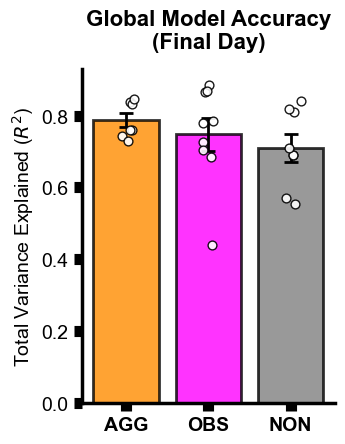

In [ ]:
# Model fits
plt.rcParams['font.family'] = 'Arial'
FS_TITLE = 16
FS_TICKS = 14
LW_AXIS = 2.5
colors = ['darkorange', 'magenta', 'grey']
groups = ['AGG', 'OBS', 'NON']

agg_r2 = scores_const[-3:, behaviors, 0:12].reshape(len(behaviors)*3, 12)
obs_r2 = scores_const[-3:, behaviors, 12:21].reshape(len(behaviors)*3, 9)
non_r2 = scores_const[-3:, behaviors, 21:].reshape(len(behaviors)*3, 8)

# --- 1. Extract and Collapse R-squared Data ---
# agg_r2 shape is (24, 12) -> (sessions*behaviors, animals)
# We average across the 24 behavioral/session slices to get 1 value per animal
r2_agg_final = np.nanmean(agg_r2, axis=0) 
r2_obs_final = np.nanmean(obs_r2, axis=0) 
r2_non_final = np.nanmean(non_r2, axis=0) 

# Clean out any potential NaNs for the stats
r2_agg_clean = r2_agg_final[~np.isnan(r2_agg_final)]
r2_obs_clean = r2_obs_final[~np.isnan(r2_obs_final)]
r2_non_clean = r2_non_final[~np.isnan(r2_non_final)]

data_list = [r2_agg_clean, r2_obs_clean, r2_non_clean]

# --- 2. Statistics ---
# Independent t-tests between the groups
p_agg_obs = stats.ttest_ind(r2_agg_clean, r2_obs_clean)[1]
p_agg_non = stats.ttest_ind(r2_agg_clean, r2_non_clean)[1]
p_obs_non = stats.ttest_ind(r2_obs_clean, r2_non_clean)[1]

# FDR Correction
raw_pvals = [p_agg_obs, p_agg_non, p_obs_non]
_, corrected_pvals, _, _ = multipletests(raw_pvals, method='fdr_bh')
p_agg_obs_c, p_agg_non_c, p_obs_non_c = corrected_pvals

def get_sig_marker(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    if p < 0.1: return '#'
    return 'n.s.'

print("--- Final Day Total R-squared Stats (FDR Corrected) ---")
print(f"AGG vs OBS: p = {p_agg_obs_c:.4f} ({get_sig_marker(p_agg_obs_c)})")
print(f"AGG vs NON: p = {p_agg_non_c:.4f} ({get_sig_marker(p_agg_non_c)})")
print(f"OBS vs NON: p = {p_obs_non_c:.4f} ({get_sig_marker(p_obs_non_c)})")

# --- 3. Plotting ---
fig, ax = plt.subplots(figsize=(4, 5))

# Calculate means and SEMs
means = [np.mean(d) for d in data_list]
sems = [stats.sem(d) for d in data_list]

# Plot Bars
x_pos = np.arange(len(groups))
ax.bar(x_pos, means, yerr=sems, capsize=5, color=colors, alpha=0.8, 
       edgecolor='black', linewidth=2, error_kw={'elinewidth': 2, 'capthick': 2})

# Overlay individual animal points (Swarm)
for i, data in enumerate(data_list):
    # Add a little jitter to x for the scatter
    x_jitter = np.random.normal(x_pos[i], 0.05, size=len(data))
    ax.scatter(x_jitter, data, color='white', edgecolor='black', 
               zorder=3, s=40, alpha=0.9)

# Aesthetics
ax.set_xticks(x_pos)
ax.set_xticklabels(groups, fontsize=FS_TICKS, fontweight='bold')
ax.set_ylabel('Total Variance Explained ($R^2$)', fontsize=FS_TICKS)
ax.set_title('Global Model Accuracy\n(Final Day)', fontsize=FS_TITLE, fontweight='bold', pad=15)

ax.tick_params(axis='y', labelsize=FS_TICKS)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(LW_AXIS)
ax.spines['bottom'].set_linewidth(LW_AXIS)

plt.tight_layout()
# plt.savefig('.\\figures\\fig5\\Final_Day_Total_R2_Comparison.svg', dpi=300)
plt.show()

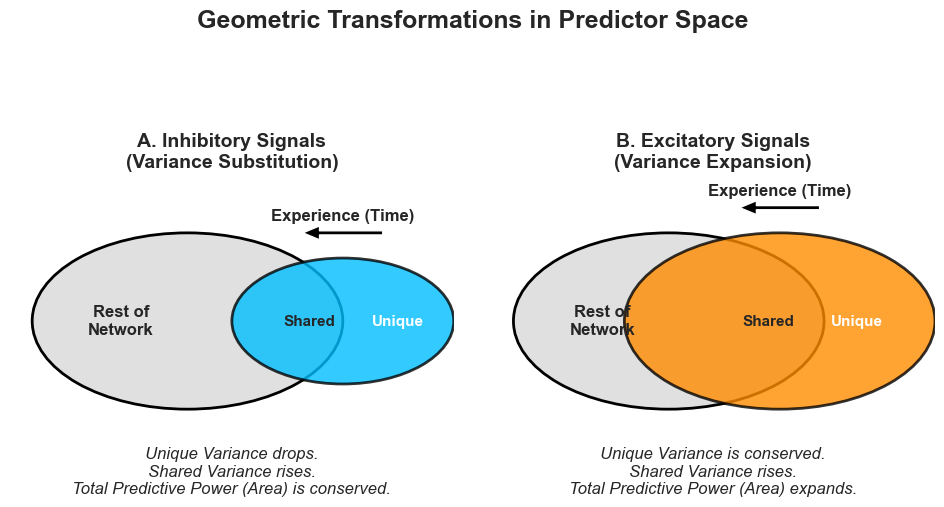

In [505]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import seaborn as sns

# --- Figure Setup ---
plt.rcParams['font.family'] = 'Arial'
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Geometric Transformations in Predictor Space', fontsize=18, fontweight='bold', y=1.05)

# Common styling
network_color = '#E0E0E0'
edge_color = 'black'
lw = 2

def draw_venn(ax, title, roi_color, roi_radius, roi_center_x, text_notes):
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    # Rest of Network (Constant across all plots)
    network = Circle((4, 5), 3.5, color=network_color, ec=edge_color, lw=lw, zorder=1)
    ax.add_patch(network)
    ax.text(2.5, 5, "Rest of\nNetwork", ha='center', va='center', fontsize=12, fontweight='bold')
    
    # ROI (Changes based on condition)
    roi = Circle((roi_center_x, 5), roi_radius, color=roi_color, ec=edge_color, lw=lw, alpha=0.8, zorder=2)
    ax.add_patch(roi)
    
    # Annotations
    ax.text(roi_center_x + (roi_radius*0.5), 5, "Unique", ha='center', va='center', fontsize=11, fontweight='bold', color='white')
    ax.text((4 + roi_center_x)/2 + 1, 5, "Shared", ha='center', va='center', fontsize=11, fontweight='bold', zorder=3)
    
    # Explanatory Text below
    ax.text(5, 0, text_notes, ha='center', va='top', fontsize=12, style='italic', 
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))

# --- PANEL A: Inhibitory (Substitution / Rotation) ---
# The ROI size is constant (Radius=2.5), but it slides closer to the network center
draw_venn(axes[0], 'A. Inhibitory Signals\n(Variance Substitution)', 'deepskyblue', 
          roi_radius=2.5, roi_center_x=7.5, 
          text_notes="Unique Variance drops.\nShared Variance rises.\nTotal Predictive Power (Area) is conserved.")

# --- PANEL B: Excitatory (Expansion / Addition) ---
# The ROI unique crescent width is conserved, but the circle grows (Radius=3.5) and shifts left
draw_venn(axes[1], 'B. Excitatory Signals\n(Variance Expansion)', 'darkorange', 
          roi_radius=3.5, roi_center_x=6.5, 
          text_notes="Unique Variance is conserved.\nShared Variance rises.\nTotal Predictive Power (Area) expands.")

# Add visual arrows to represent the "push" over time
axes[0].annotate('', xy=(6.5, 8.5), xytext=(8.5, 8.5), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=3, headwidth=10))
axes[0].text(7.5, 9, "Experience (Time)", ha='center', fontsize=12, fontweight='bold')

axes[1].annotate('', xy=(5.5, 9.5), xytext=(7.5, 9.5), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=3, headwidth=10))
axes[1].text(6.5, 10, "Experience (Time)", ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

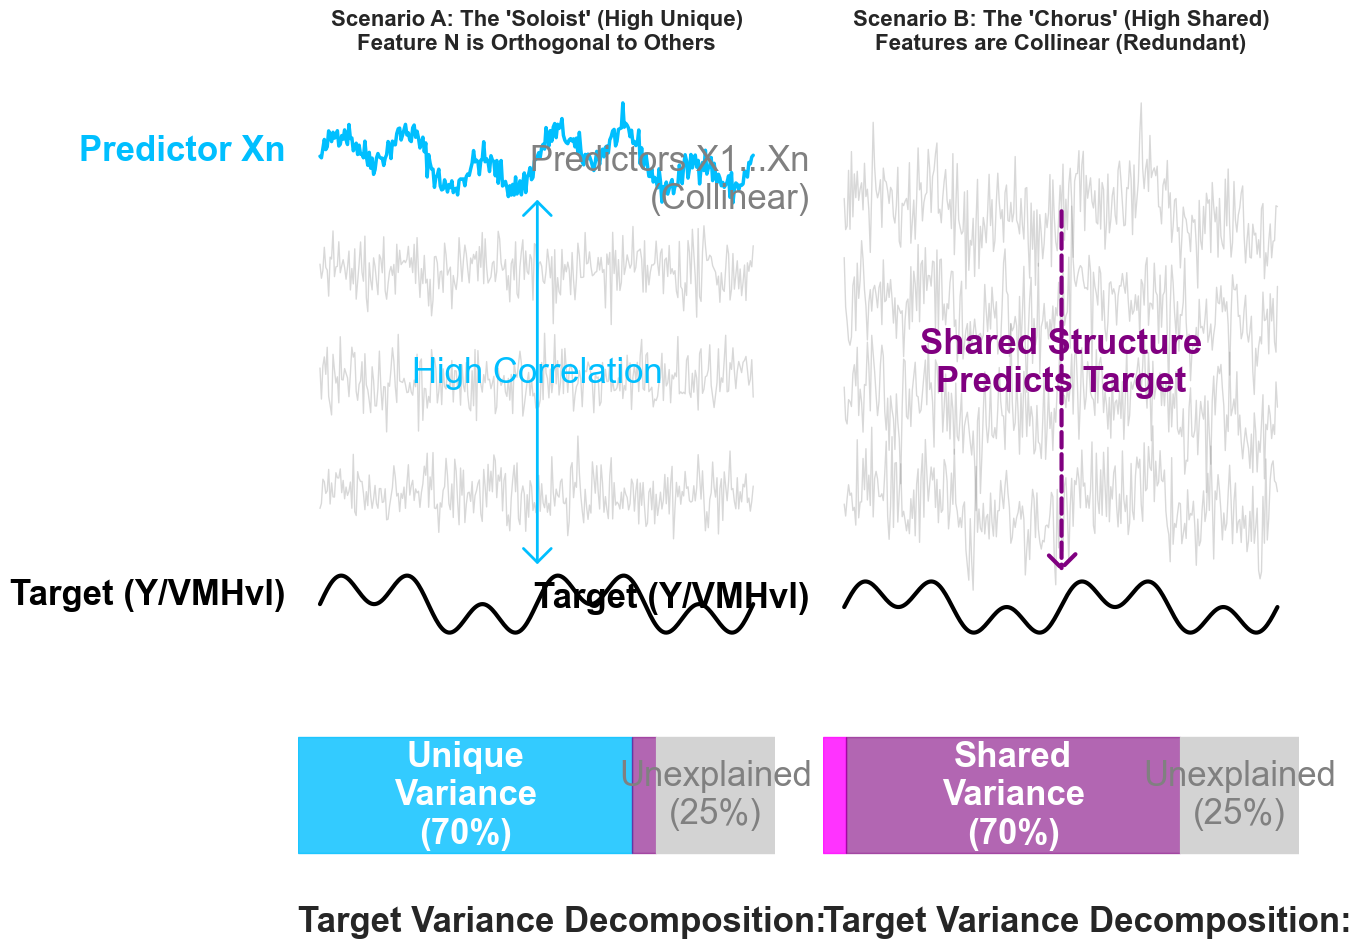

In [ ]:
from matplotlib.patches import Rectangle

# ==========================================
# SETUP & DATA GENERATION
# ==========================================
plt.rcParams['font.family'] = 'Arial'
np.random.seed(42) # for reproducible schematic noise

t = np.linspace(0, 8*np.pi, 300)

# --- Scenario A Data: High Unique Variance ---
# Target: A clear, structured signal
target_A = np.sin(t) * np.cos(t/2) 

# Predictor N (The Soloist): Highly correlated with Target
pred_N_A = target_A + np.random.normal(0, 0.2, len(t)) # Target + slight noise

# Other Predictors (Noise): Orthogonal to Target and Pred N
others_A = [np.random.normal(0, 0.5, len(t)) for _ in range(3)]


# --- Scenario B Data: High Shared Variance ---
# Target: Same clear structure
target_B = target_A 

# The Shared Component (hidden variable driving the collinearity)
shared_driver = target_B

# Predictors (The Chorus): None match perfectly on their own.
# They are all the shared driver + significant independent noise.
# They are collinear because they share the 'shared_driver'.
preds_B = [shared_driver + np.random.normal(0, 0.8, len(t)) for _ in range(4)]

# ==========================================
# PLOTTING FUNCTIONS
# ==========================================
def plot_signals(ax, target, main_pred, other_preds, title, highlight_color):
    # Plot "Other" predictors in background gray
    offset = 0
    for p in other_preds:
        ax.plot(t, p + offset, color='grey', alpha=0.3, lw=1)
        offset += 3
        
    # Plot Main Predictor (if it exists distinct from others)
    if main_pred is not None:
        ax.plot(t, main_pred + offset, color=highlight_color, lw=2.5, label='Key Predictor (Xn)')
        ax.text(t[0]-2, offset, 'Predictor Xn', color=highlight_color, fontweight='bold', ha='right')
        offset += 3
    else:
        # Scenario B case: label the top "other" predictor
        ax.text(t[0]-2, offset-3, 'Predictors X1...Xn\n(Collinear)', color='grey', ha='right')

    # Plot Target at the bottom
    target_offset = -3
    ax.plot(t, target + target_offset, 'k', lw=3, label='Target (Y)')
    ax.text(t[0]-2, target_offset, 'Target (Y/VMHvl)', color='k', fontweight='bold', ha='right')

    # Visual connections showing correlation
    if main_pred is not None:
        # Connect Xn to Target
        ax.annotate('', xy=(t[150], target_offset+1), xytext=(t[150], offset-3-1),
                    arrowprops=dict(arrowstyle='<->, head_width=0.4', color=highlight_color, lw=2))
        ax.text(t[150], (target_offset + offset-3)/2, 'High Correlation', 
                color=highlight_color, ha='center')
    else:
        # Connect all predictors down towards target generally
        ax.annotate('', xy=(t[150], target_offset+1), xytext=(t[150], offset-3),
                    arrowprops=dict(arrowstyle='->, head_width=0.4', color='purple', lw=3, ls='--'))
        ax.text(t[150], (target_offset + offset)/2 - 1, 'Shared Structure\nPredicts Target', 
                color='purple', ha='center', fontweight='bold')


    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.axis('off')

def draw_variance_bar(ax, unique_pct, shared_pct, unexplained_pct, color_unique):
    # Helper to draw schematic variance composition bars
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    # Unique Part
    rect_u = Rectangle((0, 0.2), unique_pct, 0.6, color=color_unique, alpha=0.8)
    ax.add_patch(rect_u)
    if unique_pct > 10:
        ax.text(unique_pct/2, 0.5, f'Unique\nVariance\n({unique_pct}%)', 
                ha='center', va='center', color='white', fontweight='bold')
        
    # Shared Part
    rect_s = Rectangle((unique_pct, 0.2), shared_pct, 0.6, color='purple', alpha=0.6)
    ax.add_patch(rect_s)
    if shared_pct > 10:
        ax.text(unique_pct + shared_pct/2, 0.5, f'Shared\nVariance\n({shared_pct}%)', 
                ha='center', va='center', color='white', fontweight='bold')
        
    # Unexplained Part
    rect_n = Rectangle((unique_pct + shared_pct, 0.2), unexplained_pct, 0.6, color='lightgrey', hatch='///')
    ax.add_patch(rect_n)
    ax.text(unique_pct + shared_pct + unexplained_pct/2, 0.5, f'Unexplained\n({unexplained_pct}%)', 
            ha='center', va='center', color='grey')
    
    ax.text(0, -0.2, "Target Variance Decomposition:", fontweight='bold')


# ==========================================
# MAIN FIGURE GENERATION
# ==========================================
fig = plt.figure(figsize=(14, 10))

# Layout: Top row for signals, bottom row for variance bars
gs = fig.add_gridspec(2, 2, height_ratios=[3, 1])
ax_A_sig = fig.add_subplot(gs[0, 0])
ax_B_sig = fig.add_subplot(gs[0, 1])
ax_A_var = fig.add_subplot(gs[1, 0])
ax_B_var = fig.add_subplot(gs[1, 1])

# --- Plot Scenario A ---
plot_signals(ax_A_sig, target_A, pred_N_A, others_A, 
             title="Scenario A: The 'Soloist' (High Unique)\nFeature N is Orthogonal to Others",
             highlight_color='deepskyblue')

draw_variance_bar(ax_A_var, unique_pct=70, shared_pct=5, unexplained_pct=25, color_unique='deepskyblue')

# --- Plot Scenario B ---
# For B, we pass None for main_pred to treat them all as a group
plot_signals(ax_B_sig, target_B, None, preds_B, 
             title="Scenario B: The 'Chorus' (High Shared)\nFeatures are Collinear (Redundant)",
             highlight_color='magenta') # Highlight color unused here but kept for fun sig

draw_variance_bar(ax_B_var, unique_pct=5, shared_pct=70, unexplained_pct=25, color_unique='magenta')


plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1)
# plt.savefig('./schematic_variance_explained.svg', format='svg')
plt.show()